In [6]:
import pandas as pd
import numpy as np
import os

def open_parquet_files(file_paths):
    """
    Opens parquet files and stores them in separate dataframes based on the provided file_path.
    For example, if the file_name is hip-ccg.parquet, the dataframe name will be df_hip_ccg.
    
    Args:
        file_paths (list): List of paths to parquet files.
    
    Returns:
        dict: Dictionary containing dataframe names as keys and dataframes as values.
    """
    dataframes = {}
    
    for file_path in file_paths:
        # Check if file exists
        if not os.path.exists(file_path):
            print(f"⚠️  File not found: {file_path}")
            continue
            
        try:
            # Extract the base name of the file without extension
            base_name = file_path.split('/')[-1].replace('.parquet', '')
            
            # Create a valid dataframe name by replacing hyphens with underscores
            df_name = f"df_{base_name.replace('-', '_')}"
            
            # Read the parquet file into a dataframe
            df = pd.read_parquet(file_path)
            
            # Store in dictionary and global scope
            dataframes[df_name] = df
            globals()[df_name] = df
            
            print(f"✅ Loaded {df_name}: {df.shape[0]} rows, {df.shape[1]} columns")
            
        except Exception as e:
            print(f"❌ Error loading {file_path}: {str(e)}")
    
    return dataframes

# File_paths

file_paths = [
    "/Users/sarasaudrius/EAISI/EAISI-Group-Project---NHS/data/interim/hip-ccg.parquet",
    "/Users/sarasaudrius/EAISI/EAISI-Group-Project---NHS/data/interim/knee-ccg.parquet",
    "/Users/sarasaudrius/EAISI/EAISI-Group-Project---NHS/data/interim/hip-provider.parquet",
    "/Users/sarasaudrius/EAISI/EAISI-Group-Project---NHS/data/interim/knee-provider.parquet"
]
open_parquet_files(file_paths)

✅ Loaded df_hip_ccg: 122294 rows, 81 columns
✅ Loaded df_knee_ccg: 136390 rows, 81 columns
✅ Loaded df_hip_provider: 124844 rows, 81 columns
✅ Loaded df_knee_provider: 139236 rows, 81 columns


{'df_hip_ccg':        provider_code        procedure  revision_flag     year  age_band  \
 0                00C  Hip Replacement              0  2018/19       NaN   
 1                00C  Hip Replacement              0  2018/19       NaN   
 2                00C  Hip Replacement              0  2018/19       NaN   
 3                00C  Hip Replacement              0  2018/19       NaN   
 4                00C  Hip Replacement              0  2018/19       NaN   
 ...              ...              ...            ...      ...       ...   
 122289           99Q  Hip Replacement              0  2016/17  80 to 89   
 122290           99Q  Hip Replacement              0  2016/17  80 to 89   
 122291           99Q  Hip Replacement              0  2016/17  80 to 89   
 122292           99Q  Hip Replacement              0  2016/17  80 to 89   
 122293           99Q  Hip Replacement              0  2016/17  80 to 89   
 
         gender  t0_assisted  t0_assisted_by  t0_symptom_period  \
 0   

# **Important things to keep in mind based on the description provided in references, proms_guide_V12.pdf"**

## Overview

For each patient, the PROMs dataset includes the following:
- Patient-identifiable information, which is used for linkage purposes and not made
available for wider analysis.
- A condition-specific measure of self-reported health status.
- Generic measures of self-reported health status.
- Additional questions about the patient’s own health, including whether they have preexisting conditions such as arthritis or diabetes.

Before a patient undergoes one of the four PROMs procedures, the provider should offer the
patient a PROMs questionnaire for completion. The guidance states that this should happen
in the interval between the patient being passed fit for surgery and the treatment taking
place. However, there is local discretion as to when precisely it is administered before the
procedure. Completion of the pre-operative PROMs questionnaire is voluntary for the patient
and their consent to participate must be granted for the data to be processed and used. 

## Scoring methodologies

The PROMs programme utilises a number of tested and well-established methodologies to
enable patients to rate their health status.
All patients, irrespective of their condition, are asked to complete a common set of questions
about their health status. This includes sections about the patient’s circumstances, preexisting conditions and the EQ-5DTM health questionnaire consisting of a five-dimensional
descriptive system and a visual analogue scale (EQ-VAS) developed by the EuroQol Group.
Post-operative questionnaires also contain additional questions about the surgery, such as
how the patient perceives the results of the operation and whether there were any postoperative complications, such as bleeding or wound problems.
Patients undergoing varicose vein treatment or hip and knee replacement surgery are also
asked to complete a condition-specific section.

### *EQ-5DTM*

EQ-5DTM is a standardised measure of health status developed by the EuroQol Group in
order to provide a simple, generic measure of health for clinical and economic appraisal.
Applicable to a wide range of health conditions and treatments, it provides a simple
descriptive profile and a single index value for health status that can be used in the clinical
and economic evaluation of healthcare as well as in population health surveys.
EQ-5DTM consists of two distinct sections, the EQ-5DTM descriptive system and the EQ-5DTM
visual analogue scale (EQ-VAS).
The EQ-5DTM descriptive system comprises the following five dimensions:
- Mobility
- Self-care e.g. washing and dressing
- Usual activities e.g. work, study, housework, family or leisure activities
- Pain / discomfort
- Anxiety / depression.

Each dimension has three levels: no problems, some problems, severe problems. The
respondent is asked to indicate his / her health state by ticking (or placing a cross) in the box
against the most appropriate statement in each of the five dimensions. This decision results
in a one-digit number expressing the level selected for that dimension. The digits for five
dimensions can be combined in a five-digit number string describing the respondent’s health
state, also referred to as the EQ-5DTM
’health profile’.
EQ-5DTM health states are converted into a single summary index by applying a formula that
essentially attaches values (also called ‘social preference weights’) to each of the levels in
each dimension. The index can be calculated by deducting the appropriate weights from
one, the value for full health (i.e. state 11111).
EQ-VAS consists of a simple scale, from 0 to 100, presented in a simple linear format.
Respondents are asked to rate their health state by marking the scale at the relevant point,
with zero being the worst and one hundred being the best state. See Annex 2 for more
information on the EQ-5DTM scoring system.

### *OHS and OKS*

The Oxford hip and knee scores are joint-specific outcome measure tools designed to
assess symptoms and function in patients undergoing joint replacement surgery.
The scores comprise of twelve multiple choice questions relating to the patient’s experience
of pain, ease of joint movement and ease of undertaking normal domestic activities such as
walking or climbing stairs.
Each of the 12 questions on the Oxford Hip Score and Oxford Knee Score are scored in the
same way with the score decreasing as the reported symptoms increase, i.e. become worse.
All questions are laid out similarly with response categories denoting least (or no) symptoms
scoring four and those representing greatest severity scoring zero.
The individual scores are then added together to provide a single score with 0 indicating the
worst possible and 48 indicating the highest possible score.

## Potential issues with the data

HES episodes that do not link to PROMs (unlinked episodes):
- Completion of PROMs is voluntary: patients are not obliged to take part in the PROMs
programme at either Q1 or Q2 stage.
- Lag or ‘lead in’ time before the operation: in many cases providers are administering their
Q1 questionnaire at a pre-assessment clinic up to several weeks before surgery is
scheduled. This means that a high proportion of patients who had episodes early in the
year would not have been invited to take part. Some patients with episodes in April would
not have completed Q1 questionnaires and many patients who had completed Q1s in
April would not have had their operation until several weeks or even months later. This
will have the effect of underestimating actual linkage performance.
- Provider mapping issues: there are instances where the Q1 may be administered to a
patient at one hospital and the operation performed at another. This may be due to
provider subcontracting arrangements, patient choice or shared pathways. The matching
algorithm can take many of these provider-to-provider relationships into account where
they are known but there will always be relationships between providers that are not
recognised.
- During the period April to September 2009, a significant number of providers were
submitting PROMs data to the Patient Outcomes in Surgery (POIS) audit rather than the
Department of Health PROMs programme. This has reduced the number of
questionnaires received for those procedures in the first part of the year. After September
those trusts involved in the POIS audit transferred to the national PROMs programme.

### *Missing Values*

In instances where a patient may have either declined to answer or accidentally missed a
question, a default value is inserted to indicate a null value. For the majority of the multiple
choice questions, NULL values are replaced with a 9. For the EQ-5DTM VAS, 999 is used
because in that case 9 is a valid response.

The second exception is for the Oxford orthopaedic scores, for which the PROMs
programme adopts the permitted option to impute of missing values as the average of
present responses provided that no more than two responses are missing. Where more than
two responses are missing, the overall score is not calculated.


### *Time differences*

The second exception is for the Oxford orthopaedic scores, for which the PROMs
programme adopts the permitted option to impute of missing values as the average of
present responses provided that no more than two responses are missing. Where more than
two responses are missing, the overall score is not calculated.

### **General data inspection of all files**

In [14]:
# List of dataframe variable names
df_names = ["df_hip_ccg", "df_knee_ccg", "df_hip_provider", "df_knee_provider"]

for df_name in df_names:
    print(f"\n--- {df_name} ---")
    df = globals().get(df_name)
    if df is not None:
        print("Columns:", df.columns.tolist())
        print("Missing values per column:\n", df.isnull().sum())
        print("Describe:\n", df.describe(include='all'))
    else:
        print(f"{df_name} not loaded.")


--- df_hip_ccg ---
Columns: ['provider_code', 'procedure', 'revision_flag', 'year', 'age_band', 'gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility', 't0_self_care', 't0_activity', 't0_discomfort', 't0_anxiety', 't0_eq5d_index_profile', 't0_eq5d_index', 't1_assisted', 't1_assisted_by', 't1_living_arrangements', 't1_disability', 't1_mobility', 't1_self_care', 't1_activity', 't1_discomfort', 't1_anxiety', 't1_satisfaction', 't1_sucess', 't1_allergy', 't1_bleeding', 't1_wound', 't1_urine', 't1_further_surgery', 't1_readmitted', 't1_eq5d_index_profile', 't1_eq5d_index', 'ohs_eq5d_index_t1_predicted', 't0_eq_vas', 't1_eq_vas', 'ohs_eq_vas_t1_predicted', 'ohs_t0_pain', 'ohs_t0_sudden_pain', 'ohs_t0_night_pain', 'ohs_t0_washing', 'ohs

In [32]:
# Missing values for t0 and t1 scores, specifically for t1_eq5d_index, t1_eq5d_vas, ohs_score for df_hip_provider

df = globals().get("df_hip_provider")
if df is not None:
    columns_of_interest = [
        "t0_eq_vas", "ohs_t0_score",
        "t1_eq_vas", "ohs_t1_score"
    ]
    print("\nMissing values for columns of interest:")
    for col in columns_of_interest:
        if col in df.columns:
            missing = df[col].isnull().sum()
            total = len(df)
            print(f"{col}: {missing} missing ({missing/total:.2%})")
        else:
            print(f"{col}: column not found in df_hip_provider")

    print("\nNumber of patients with answers at t0 and t1 of the OHS:")
    t0_answered = df.dropna(subset=["ohs_t0_score"]).shape[0]
    t1_answered = df.dropna(subset=["ohs_t1_score"]).shape[0]
    print(f"Answered all t0 scores: {t0_answered} / {len(df)}")
    print(f"Answered all t1 scores: {t1_answered} / {len(df)}")
    print("\nNumber of patients with answers at t0 and t1 of the EQ5D and replace 999 with na:")
    t0_answered = df.replace(999, np.nan).dropna(subset=["t0_eq_vas"]).shape[0]
    t1_answered = df.replace(999, np.nan).dropna(subset=["t1_eq_vas"]).shape[0]
    print(f"Answered all t0 scores: {t0_answered} / {len(df)}")
    print(f"Answered all t1 scores: {t1_answered} / {len(df)}")
else:
    print("df_hip_provider not loaded.")


Missing values for columns of interest:
t0_eq_vas: 0 missing (0.00%)
ohs_t0_score: 1417 missing (1.14%)
t1_eq_vas: 0 missing (0.00%)
ohs_t1_score: 1441 missing (1.15%)

Number of patients with answers at t0 and t1 of the OHS:
Answered all t0 scores: 123427 / 124844
Answered all t1 scores: 123403 / 124844

Number of patients with answers at t0 and t1 of the EQ5D and replace 999 with na:
Answered all t0 scores: 113575 / 124844
Answered all t1 scores: 118764 / 124844


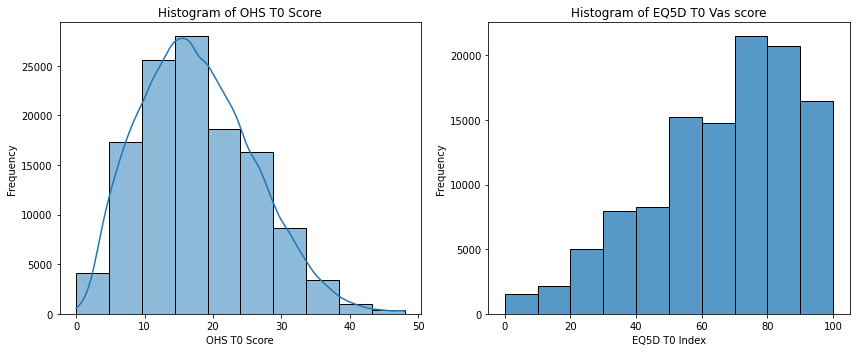

In [35]:
# Histogram for ohs_t0_score and t0_eq5d_vas with seaborn in df_hip_provider

import seaborn as sns
import matplotlib.pyplot as plt

df = globals().get("df_hip_provider")
if df is not None:
    plt.figure(figsize=(12, 5))

    # Histogram for ohs_t0_score
    plt.subplot(1, 2, 1)
    sns.histplot(df['ohs_t0_score'].dropna(), bins=10, kde=True)
    plt.title('Histogram of OHS T0 Score')
    plt.xlabel('OHS T0 Score')
    plt.ylabel('Frequency')

    # Histogram for t0_eq5d_index
    plt.subplot(1, 2, 2)
    #Drop NA and exclude = 999
    sns.histplot(df['t0_eq_vas'].dropna().replace(999, np.nan).dropna(), bins=10)
    plt.title('Histogram of EQ5D T0 Vas score')
    plt.xlabel('EQ5D T0 Index')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

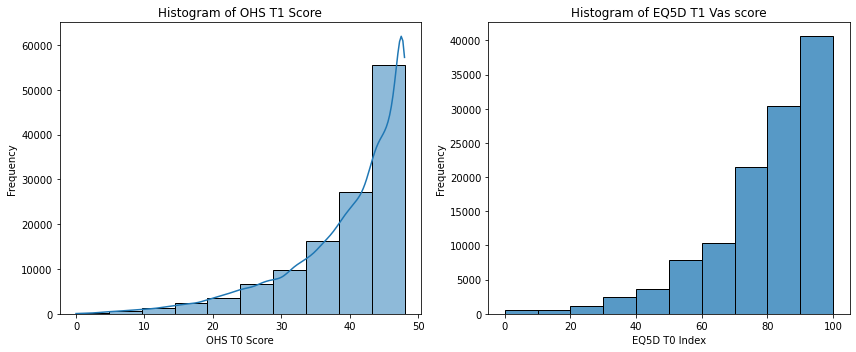

In [36]:
# Histogram for ohs_t0_score and t0_eq5d_vas with seaborn in df_hip_provider

df = globals().get("df_hip_provider")
if df is not None:
    plt.figure(figsize=(12, 5))

    # Histogram for ohs_t1_score
    plt.subplot(1, 2, 1)
    sns.histplot(df['ohs_t1_score'].dropna(), bins=10, kde=True)
    plt.title('Histogram of OHS T1 Score')
    plt.xlabel('OHS T0 Score')
    plt.ylabel('Frequency')

    # Histogram for t1_eq5d_index
    plt.subplot(1, 2, 2)
    #Drop NA and exclude = 999
    sns.histplot(df['t1_eq_vas'].dropna().replace(999, np.nan).dropna(), bins=10)
    plt.title('Histogram of EQ5D T1 Vas score')
    plt.xlabel('EQ5D T0 Index')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

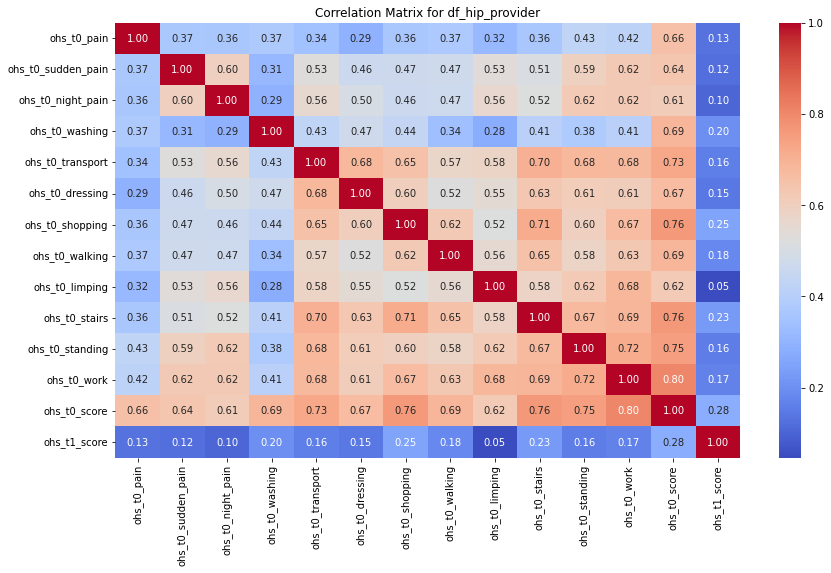

In [51]:
# Correlation matrices for df_hip_provider with all numerical columns for ohs_t0_score, ohs_t1_score, t0_eq5d_vas, t1_eq5d_vas

# subset with numerical columns for ohs_t0_score
df = globals().get("df_hip_provider")
df_ohs_hip_provider = df[['ohs_t0_pain', 'ohs_t0_sudden_pain', 'ohs_t0_night_pain', 
                           'ohs_t0_washing', 'ohs_t0_transport', 'ohs_t0_dressing', 
                           'ohs_t0_shopping', 'ohs_t0_walking', 'ohs_t0_limping', 
                           'ohs_t0_stairs', 'ohs_t0_standing', 'ohs_t0_work', 
                        'ohs_t0_score','ohs_t1_score']]





if df_ohs_hip_provider is not None:
    plt.figure(figsize=(14, 8))
    corr = df_ohs_hip_provider.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title('Correlation Matrix for df_hip_provider')
    plt.show()


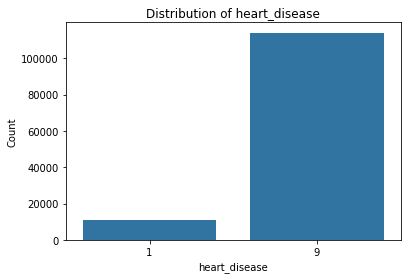


Statistical summary for heart_disease:
9    114100
1     10744
Name: heart_disease, dtype: int64



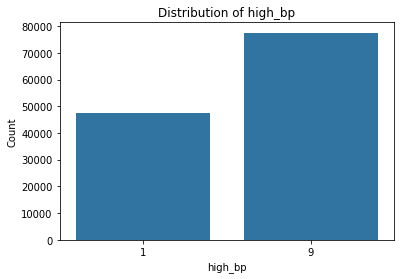


Statistical summary for high_bp:
9    77501
1    47343
Name: high_bp, dtype: int64



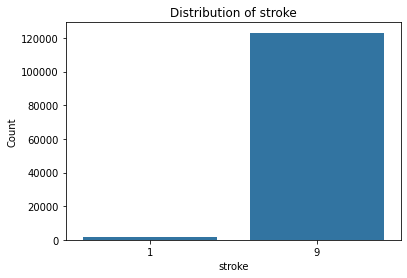


Statistical summary for stroke:
9    123155
1      1689
Name: stroke, dtype: int64



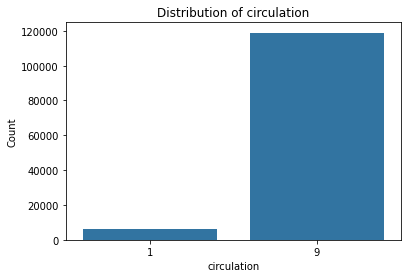


Statistical summary for circulation:
9    118922
1      5922
Name: circulation, dtype: int64



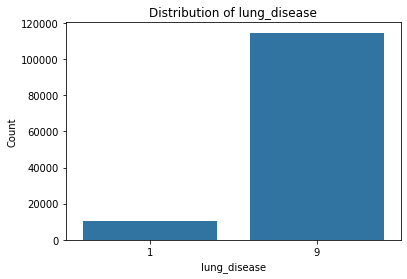


Statistical summary for lung_disease:
9    114478
1     10366
Name: lung_disease, dtype: int64



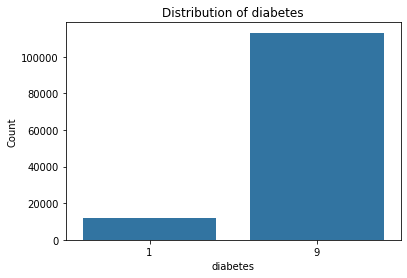


Statistical summary for diabetes:
9    113090
1     11754
Name: diabetes, dtype: int64



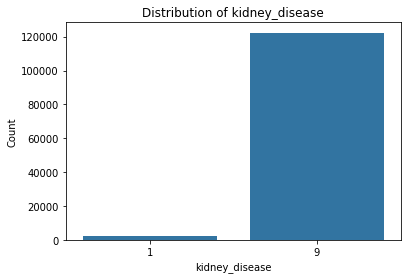


Statistical summary for kidney_disease:
9    122324
1      2520
Name: kidney_disease, dtype: int64



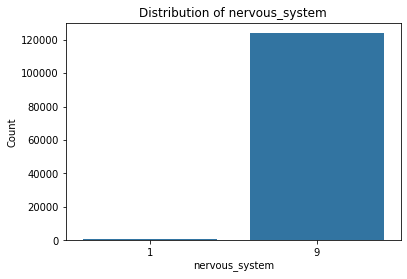


Statistical summary for nervous_system:
9    123804
1      1040
Name: nervous_system, dtype: int64



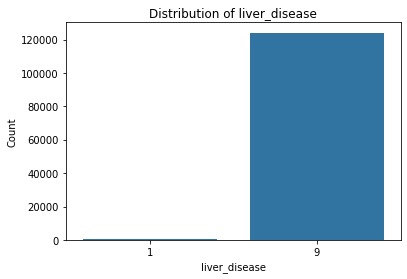


Statistical summary for liver_disease:
9    124061
1       783
Name: liver_disease, dtype: int64



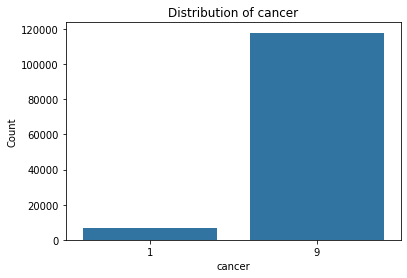


Statistical summary for cancer:
9    117888
1      6956
Name: cancer, dtype: int64



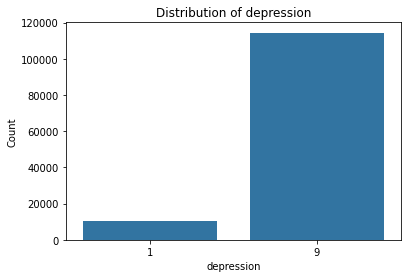


Statistical summary for depression:
9    114426
1     10418
Name: depression, dtype: int64



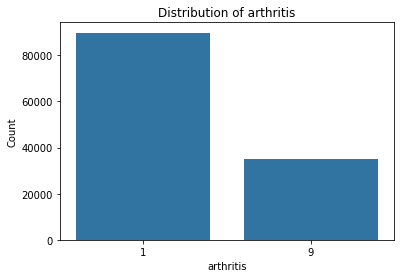


Statistical summary for arthritis:
1    89812
9    35032
Name: arthritis, dtype: int64



In [52]:
# Explore these variables visually and statistically:  'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis',

df = globals().get("df_hip_provider")
if df is not None:
    health_conditions = [
        'heart_disease', 'high_bp', 'stroke', 'circulation', 
        'lung_disease', 'diabetes', 'kidney_disease', 
        'nervous_system', 'liver_disease', 'cancer', 
        'depression', 'arthritis'
    ]
    
    for condition in health_conditions:
        if condition in df.columns:
            plt.figure(figsize=(6, 4))
            sns.countplot(x=condition, data=df)
            plt.title(f'Distribution of {condition}')
            plt.xlabel(condition)
            plt.ylabel('Count')
            plt.show()
            
            # Statistical summary
            counts = df[condition].value_counts(dropna=False)
            print(f"\nStatistical summary for {condition}:\n{counts}\n")
        else:
            print(f"{condition}: column not found in df_hip_provider")

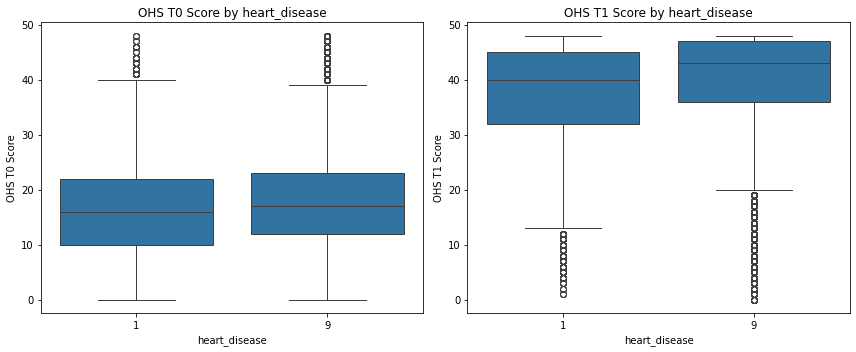

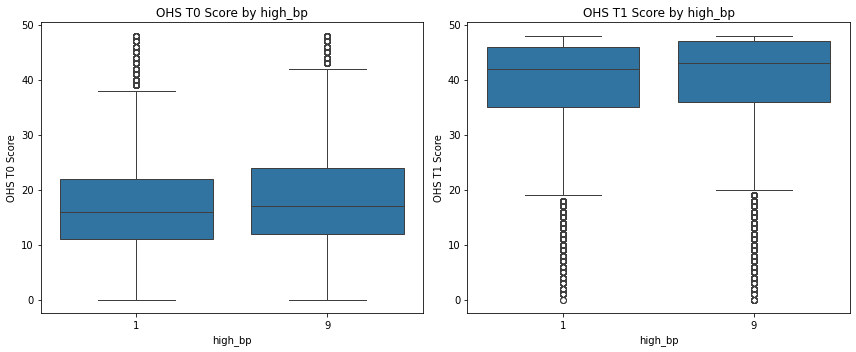

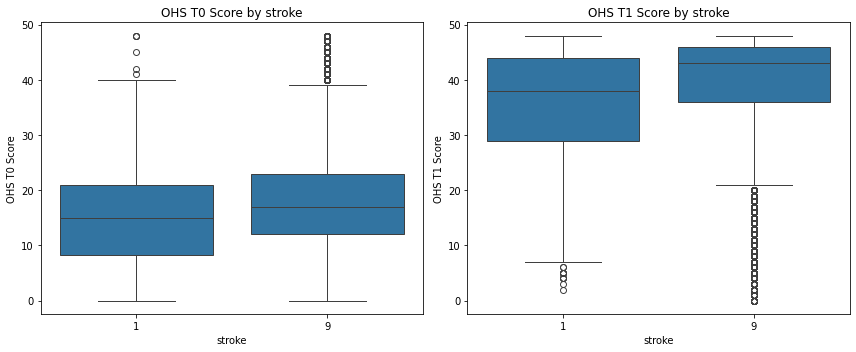

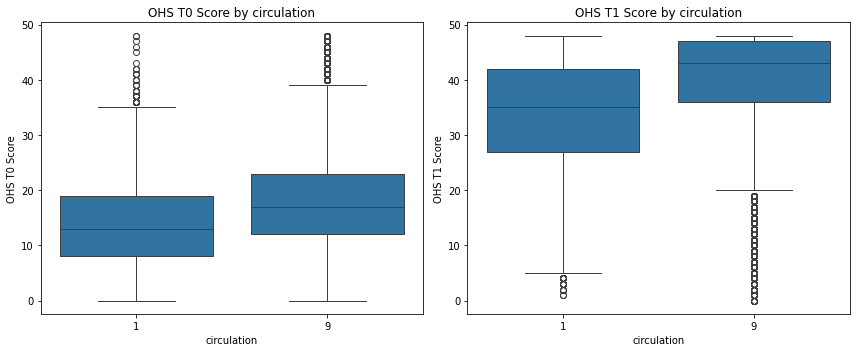

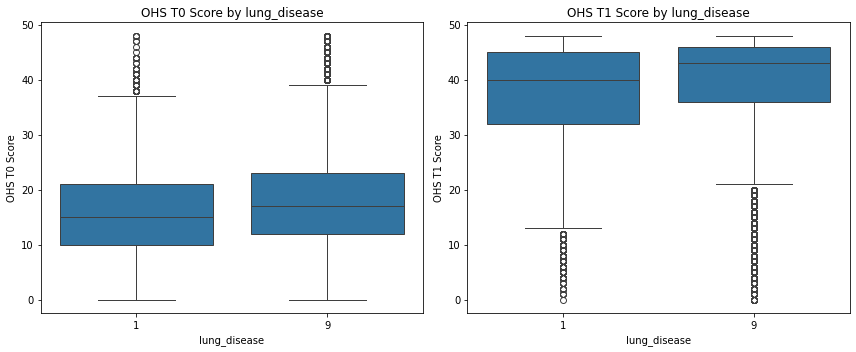

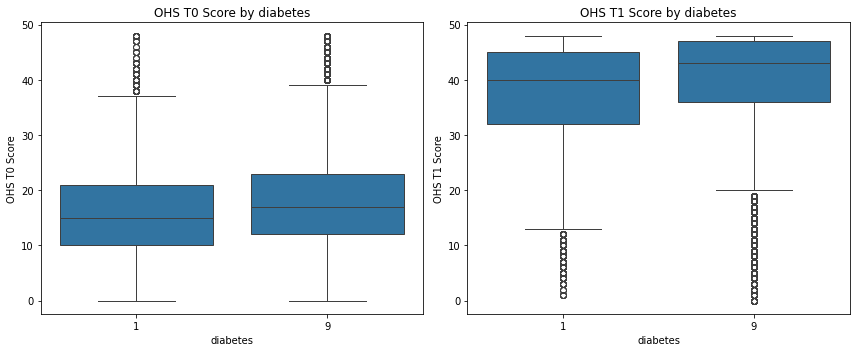

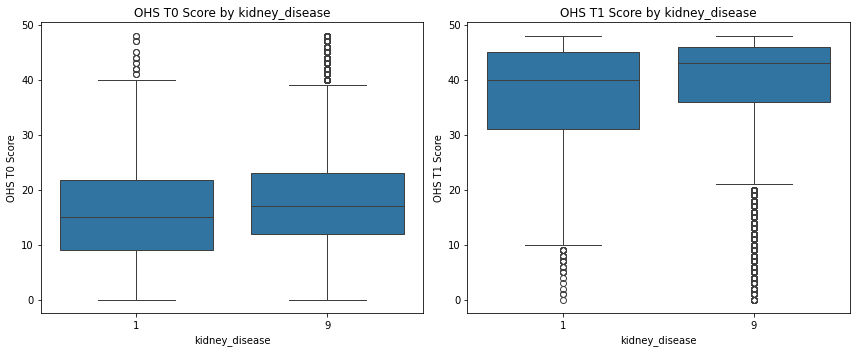

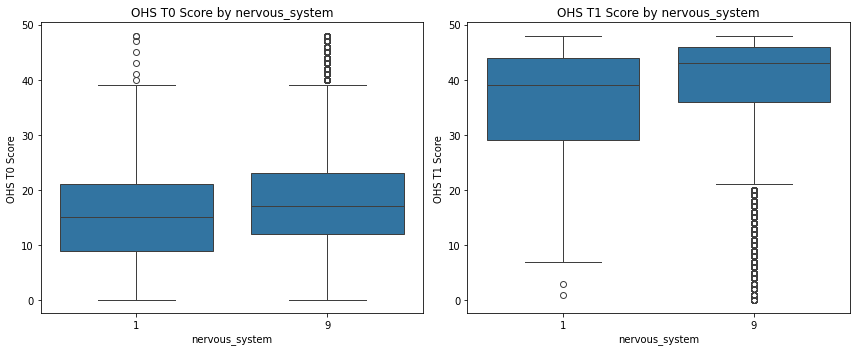

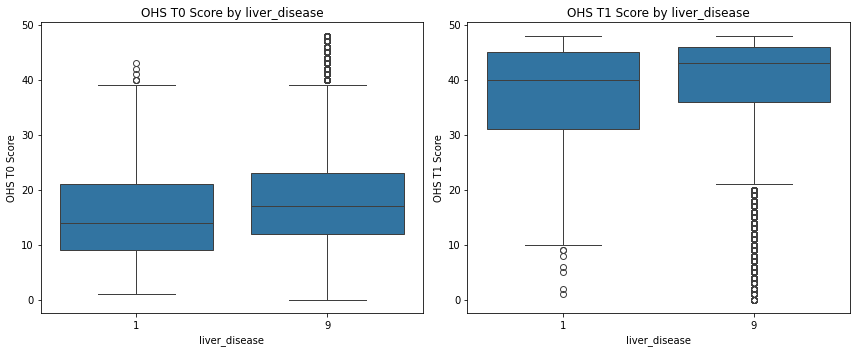

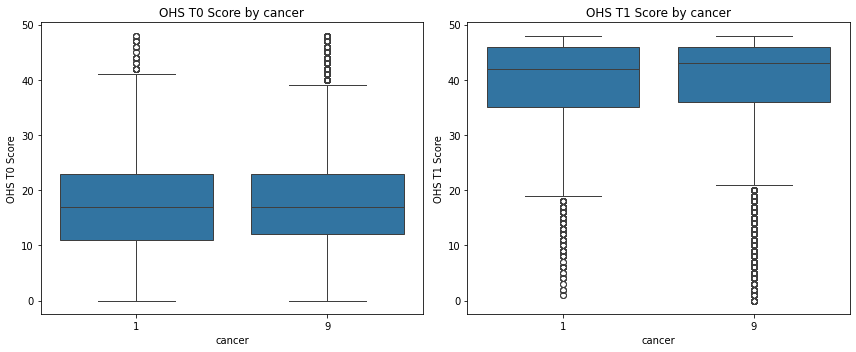

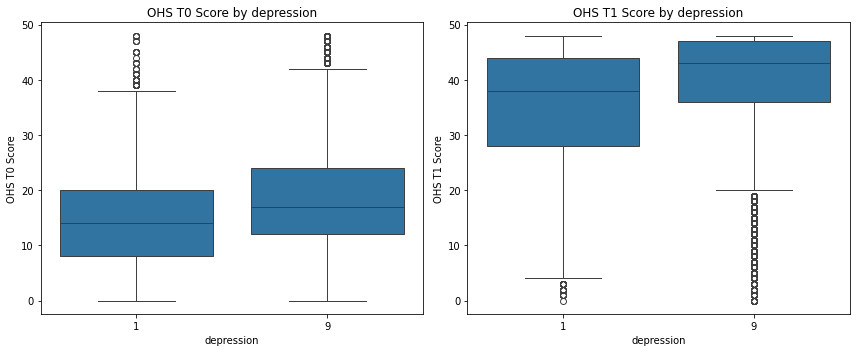

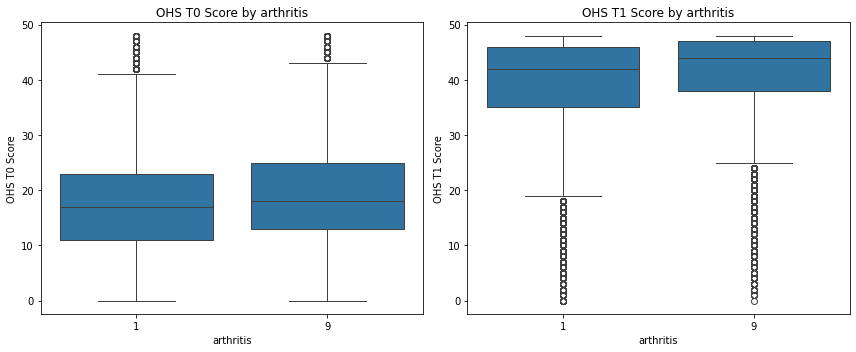

In [53]:
# Plot each condition against ohs_t0_score and ohs_t1_score

df = globals().get("df_hip_provider")
if df is not None:
    health_conditions = [
        'heart_disease', 'high_bp', 'stroke', 'circulation', 
        'lung_disease', 'diabetes', 'kidney_disease', 
        'nervous_system', 'liver_disease', 'cancer', 
        'depression', 'arthritis'
    ]
    
    for condition in health_conditions:
        if condition in df.columns:
            plt.figure(figsize=(12, 5))

            # Boxplot for ohs_t0_score
            plt.subplot(1, 2, 1)
            sns.boxplot(x=condition, y='ohs_t0_score', data=df)
            plt.title(f'OHS T0 Score by {condition}')
            plt.xlabel(condition)
            plt.ylabel('OHS T0 Score')

            # Boxplot for ohs_t1_score
            plt.subplot(1, 2, 2)
            sns.boxplot(x=condition, y='ohs_t1_score', data=df)
            plt.title(f'OHS T1 Score by {condition}')
            plt.xlabel(condition)
            plt.ylabel('OHS T1 Score')

            plt.tight_layout()
            plt.show()
        else:
            print(f"{condition}: column not found in df_hip_provider")

# Further exploration. Looking for a compact overview to decide how to proceed.

In [13]:
import pandas as pd
import os

# Define row variables
row_vars = [
    "t0_eq5d_index", "t1_eq5d_index", "ohs_eq5d_index_t1_predicted",
    "t0_eq_vas", "t1_eq_vas", "ohs_eq_vas_t1_predicted",
    "ohs_t0_score", "ohs_t1_score", "ohs_ohs_t1_predicted",
    "ohs_t0_pain", "ohs_t0_sudden_pain", "ohs_t0_night_pain",
    "ohs_t1_pain", "ohs_t1_sudden_pain", "ohs_t1_night_pain",
    "provider_code", "t1_sucess"
]

# Directory with .parquet files
data_dir = r"C:\Users\olifa\OneDrive\Documenten\GitHub\EAISI-Group-Project---NHS\data\interim"
parquet_files = [f for f in os.listdir(data_dir) if f.endswith(".parquet")]

# Loop through files and generate summary per file
for file in parquet_files:
    full_path = os.path.join(data_dir, file)
    df = pd.read_parquet(full_path)

    available_vars = [var for var in row_vars if var in df.columns]
    total_rows = len(df)

    missing = df[available_vars].isna().sum()
    flagged = pd.Series(0, index=available_vars)

    for var in available_vars:
        if var == "provider_code":
            # Count values that start with '89'
            flagged[var] = df[var].astype(str).str.startswith("89").sum()
        else:
            flagged[var] = df[var].isin([9, 999]).sum()

    valid = total_rows - missing - flagged
    valid_pct = (valid / total_rows * 100).round(2)

    summary = pd.DataFrame({
        "total_rows": total_rows,
        "missing_count": missing,
        "flagged_count": flagged,
        "valid_count": valid,
        "valid_pct": valid_pct
    })

    print(f"\n📄 Summary for: {file}")
    display(summary)


📄 Summary for: hip-ccg.parquet


,total_rows,missing_count,flagged_count,valid_count,valid_pct
t0_eq5d_index,122294,6882,0,115412,94.37
t1_eq5d_index,122294,5257,0,117037,95.70
ohs_eq5d_index_t1_predicted,122294,11774,0,110520,90.37
t0_eq_vas,122294,0,11077,111217,90.94
t1_eq_vas,122294,0,5954,116340,95.13
ohs_eq_vas_t1_predicted,122294,16084,0,106210,86.85
ohs_t0_score,122294,1398,4181,116715,95.44
ohs_t1_score,122294,1408,181,120705,98.70
ohs_ohs_t1_predicted,122294,2918,0,119376,97.61
ohs_t0_pain,122294,0,183,122111,99.85



📄 Summary for: hip-provider.parquet


,total_rows,missing_count,flagged_count,valid_count,valid_pct
t0_eq5d_index,124844,7020,0,117824,94.38
t1_eq5d_index,124844,5377,0,119467,95.69
ohs_eq5d_index_t1_predicted,124844,13006,0,111838,89.58
t0_eq_vas,124844,0,11312,113532,90.94
t1_eq_vas,124844,0,6099,118745,95.11
ohs_eq_vas_t1_predicted,124844,17397,0,107447,86.07
ohs_t0_score,124844,1417,4268,119159,95.45
ohs_t1_score,124844,1441,186,123217,98.70
ohs_ohs_t1_predicted,124844,4038,0,120806,96.77
ohs_t0_pain,124844,0,183,124661,99.85



📄 Summary for: knee-ccg.parquet


,total_rows,missing_count,flagged_count,valid_count,valid_pct
t0_eq5d_index,136390,7360,0,129030,94.60
t1_eq5d_index,136390,6129,0,130261,95.51
t0_eq_vas,136390,0,12755,123635,90.65
t1_eq_vas,136390,0,6420,129970,95.29
provider_code,136390,0,0,136390,100.00
t1_sucess,136390,0,1736,134654,98.73



📄 Summary for: knee-provider.parquet


,total_rows,missing_count,flagged_count,valid_count,valid_pct
t0_eq5d_index,139236,7500,0,131736,94.61
t1_eq5d_index,139236,6274,0,132962,95.49
t0_eq_vas,139236,0,12986,126250,90.67
t1_eq_vas,139236,0,6571,132665,95.28
provider_code,139236,0,0,139236,100.00
t1_sucess,139236,0,1766,137470,98.73


# Now I want to eplore further the improvement registered in each file

C:\Users\olifa\AppData\Local\Temp\ipykernel_8416\1855133481.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("year")[["t0_eq5d_index", "t1_eq5d_index", "t1_sucess"]].mean()


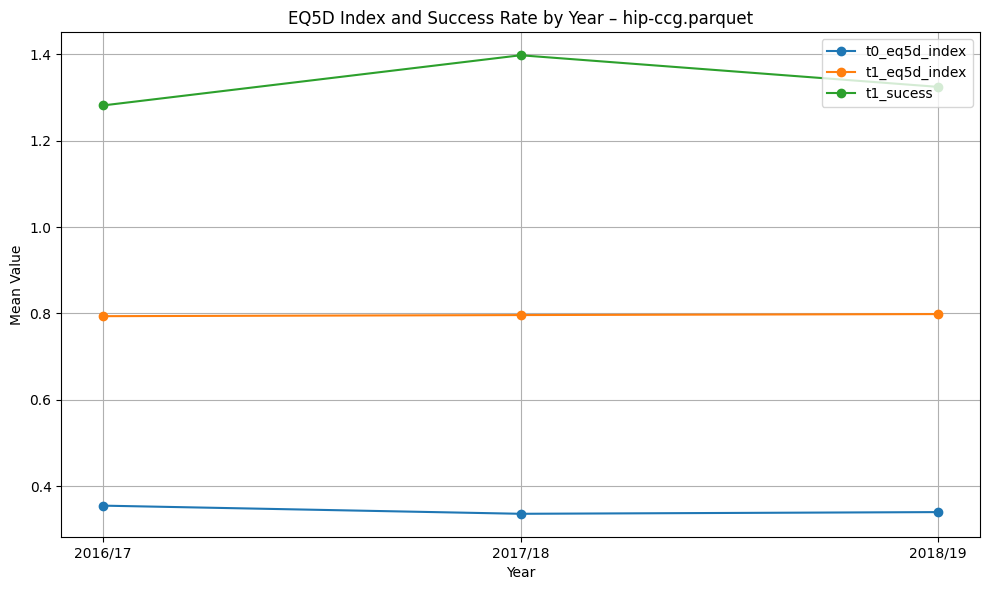

C:\Users\olifa\AppData\Local\Temp\ipykernel_8416\1855133481.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("year")[["t0_eq5d_index", "t1_eq5d_index", "t1_sucess"]].mean()


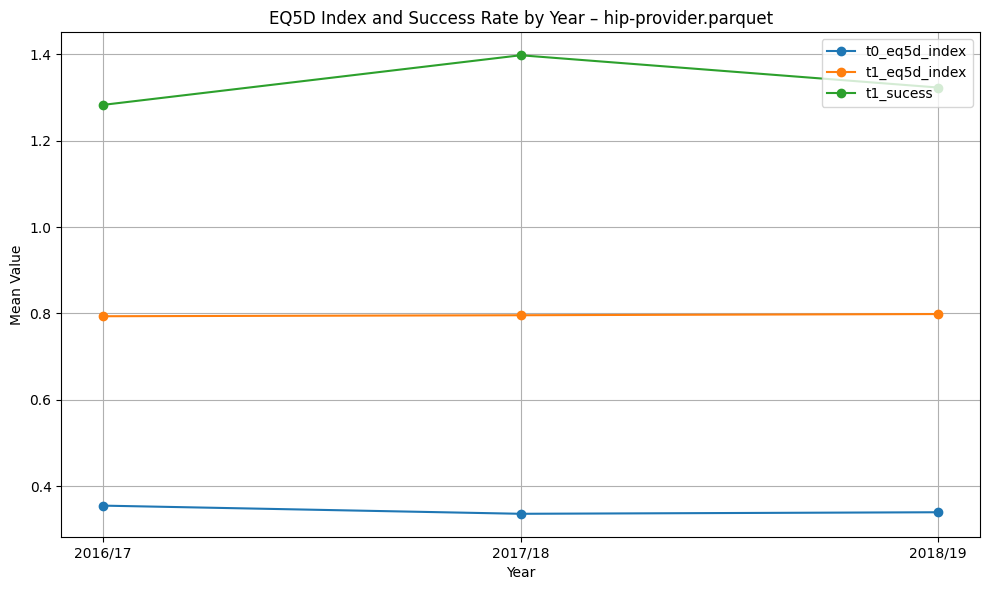

C:\Users\olifa\AppData\Local\Temp\ipykernel_8416\1855133481.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("year")[["t0_eq5d_index", "t1_eq5d_index", "t1_sucess"]].mean()


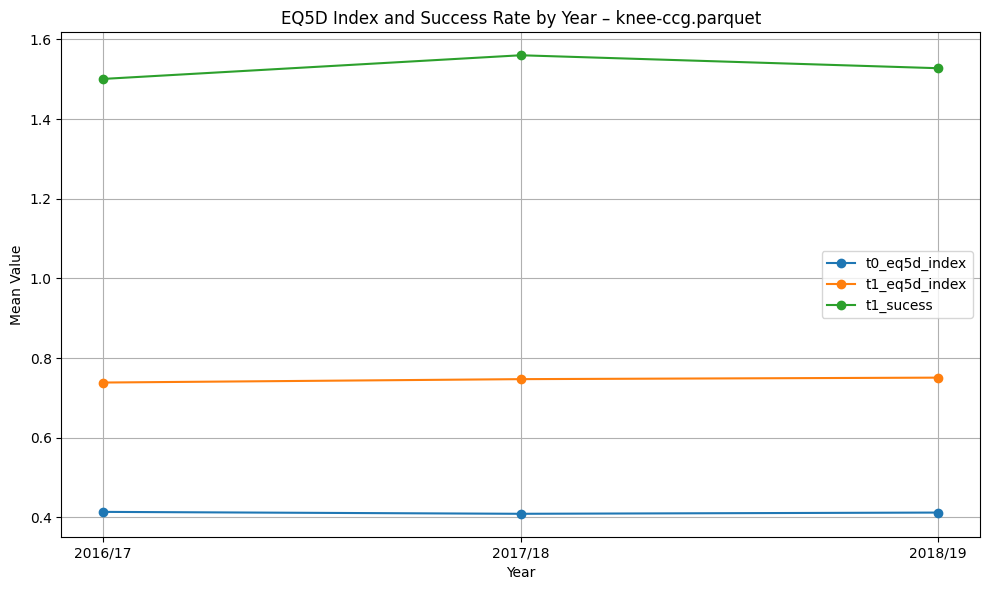

C:\Users\olifa\AppData\Local\Temp\ipykernel_8416\1855133481.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("year")[["t0_eq5d_index", "t1_eq5d_index", "t1_sucess"]].mean()


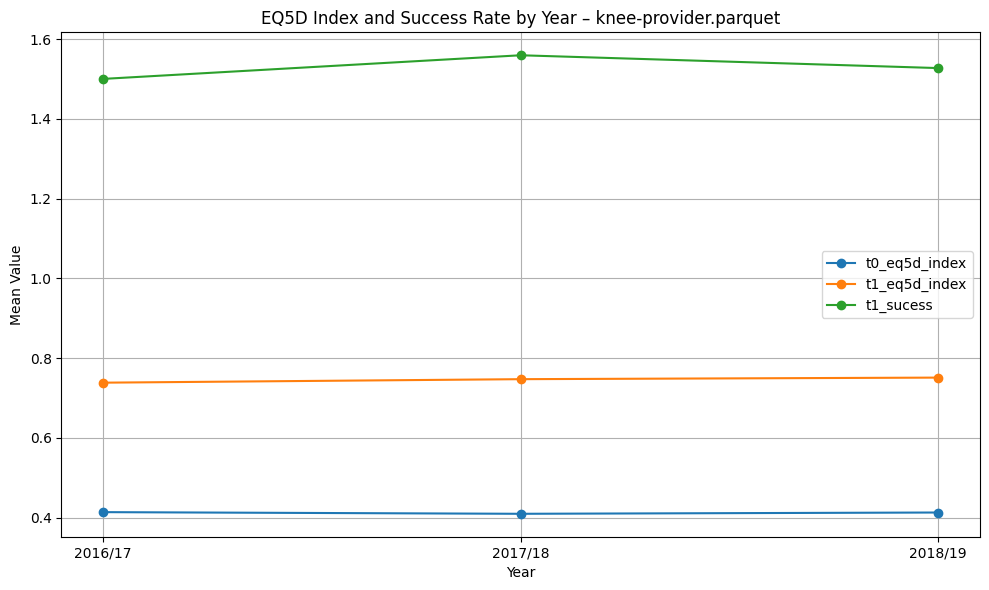

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Folder containing .parquet files
data_dir = "C:\\Users\\olifa\\OneDrive\\Documenten\\GitHub\\EAISI-Group-Project---NHS\\data\\interim"  
parquet_files = [f for f in os.listdir(data_dir) if f.endswith(".parquet")]

# Loop through each file
for file in parquet_files:
    full_path = os.path.join(data_dir, file)
    df = pd.read_parquet(full_path)

    # Check if required columns exist
    required_vars = ["t0_eq5d_index", "t1_eq5d_index", "t1_sucess", "year"]
    if all(var in df.columns for var in required_vars):
        # Group by year and calculate mean values
        grouped = df.groupby("year")[["t0_eq5d_index", "t1_eq5d_index", "t1_sucess"]].mean()

        # Plot
        plt.figure(figsize=(10, 6))
        for col in grouped.columns:
            plt.plot(grouped.index, grouped[col], marker='o', label=col)

        plt.title(f"EQ5D Index and Success Rate by Year – {file}")
        plt.xlabel("Year")
        plt.ylabel("Mean Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Skipping {file}: missing one or more required columns.")